# Single-wave SHRED prototype with 10 QR sensors

## Overview

This notebook trains a SHRED model on one synthetic wave trajectory using 10 QR-placed sensors. The goal is to keep the prototype minimal and close to the repo's actual training API.

- Load one trajectory from `data/wave_1d.npz`
- Choose 10 sensors with greedy QR/POD placement
- Build lagged sensor windows
- Train SHRED on the single sample
- Compare the true wave and reconstruction over time

## Notebook map

1. Setup and data loading
2. Sensor selection and window construction
3. SHRED training
4. Snapshot evaluation and validation metrics
5. Test-set animation

In [ ]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler

repo_root = Path.cwd().resolve()
if not (repo_root / 'src' / 'get_shredded').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src'))

from get_shredded import SHRED, TimeSeriesDataset, fit
from get_shredded.data import build_sensor_windows, qr_place


In [39]:
data_path = repo_root / 'data' / 'wave_1d.npz'
with np.load(data_path) as payload:
    field = np.asarray(payload['field'], dtype=np.float32)
    x = np.asarray(payload['x'], dtype=np.float64)
    t = np.asarray(payload['t'], dtype=np.float64)

wave = field[1]
n_time, n_state = wave.shape
print(f'Wave shape: {wave.shape}; x points: {len(x)}')
print(f'First and last time values: {t[0]:.3f}, {t[-1]:.3f}')

Wave shape: (500, 256); x points: 256
First and last time values: 0.000, 2.000


## 2. Sensor placement and lagged windows

Here we choose 10 QR sensors and convert the physical wave into the lagged sensor windows used by SHRED.

In [40]:
num_sensors = 10
lags = 10

sensor_locations, _ = qr_place(wave.T, num_sensors)
print('Selected QR sensor indices:', sensor_locations)
print('Sensor x-positions:', x[sensor_locations])

n_windows = n_time - lags
train_end = int(0.6 * n_windows)
val_end = int(0.8 * n_windows)

train_indices = np.arange(0, train_end)
valid_indices = np.arange(train_end, val_end)
test_indices = np.arange(val_end, n_windows)

scaler = MinMaxScaler().fit(wave[train_indices])
transformed_wave = scaler.transform(wave).astype(np.float32)

all_sensor_windows = build_sensor_windows(transformed_wave, sensor_locations, lags)
train_in = torch.tensor(all_sensor_windows[train_indices], dtype=torch.float32)
valid_in = torch.tensor(all_sensor_windows[valid_indices], dtype=torch.float32)
test_in = torch.tensor(all_sensor_windows[test_indices], dtype=torch.float32)

train_out = torch.tensor(transformed_wave[train_indices + lags - 1], dtype=torch.float32)
valid_out = torch.tensor(transformed_wave[valid_indices + lags - 1], dtype=torch.float32)
test_out = torch.tensor(transformed_wave[test_indices + lags - 1], dtype=torch.float32)

train_ds = TimeSeriesDataset(train_in, train_out)
valid_ds = TimeSeriesDataset(valid_in, valid_out)
test_ds = TimeSeriesDataset(test_in, test_out)

print(f'Train windows: {len(train_ds)}, validation windows: {len(valid_ds)}, test windows: {len(test_ds)}')
print(f'Sensor window shape: {train_in.shape}')

Selected QR sensor indices: [238  17 214  41  65 190  90 165 140 115]
Sensor x-positions: [1.86666667 0.13333333 1.67843137 0.32156863 0.50980392 1.49019608
 0.70588235 1.29411765 1.09803922 0.90196078]
Train windows: 294, validation windows: 98, test windows: 98
Sensor window shape: torch.Size([294, 10, 10])


## 3. Train SHRED

This section trains the recurrent decoder on the lagged sensor windows.

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SHRED(
    input_size=num_sensors,
    output_size=n_state,
    hidden_size=64,
    hidden_layers=2,
    l1=350,
    l2=400,
    dropout=0.0,
    recurrent_cell='gru',
).to(device)

train_in = train_in.to(device)
valid_in = valid_in.to(device)
test_in = test_in.to(device)
train_ds = TimeSeriesDataset(train_in, train_out.to(device))
valid_ds = TimeSeriesDataset(valid_in, valid_out.to(device))
test_ds = TimeSeriesDataset(test_in, test_out.to(device))

history = fit(
    model,
    train_ds,
    valid_ds,
    batch_size=32,
    num_epochs=2000,
    lr=1e-3,
    verbose=True,
    patience=200,
)

print(f'Training finished. Validation history length: {len(history)}')
print(f'Final validation error: {history[-1].item():.4f}')

# Plot the validation curve over training.
# FIT records validation values every 20 epochs, so the x-axis is the epoch number.
validation_epochs = np.arange(1, len(history) + 1) * 20

plt.figure(figsize=(8, 4))
plt.plot(validation_epochs, history.numpy(), marker='o', linewidth=2, color='tab:blue')
plt.xlabel('Epoch')
plt.ylabel('Relative L2 validation error')
plt.title('SHRED validation curve')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Best validation error: {history.min().item():.4f} at epoch {validation_epochs[int(history.argmin().item())]}')

train SHRED:   0%|          | 0/2000 [00:00<?, ?it/s]

## 4. Snapshot evaluation and validation

This section evaluates the trained model on the held-out test set and shows the first snapshot plus the validation curve.

Relative L2 error on test set: 0.4664


Relative L2 error on test set: 0.4664


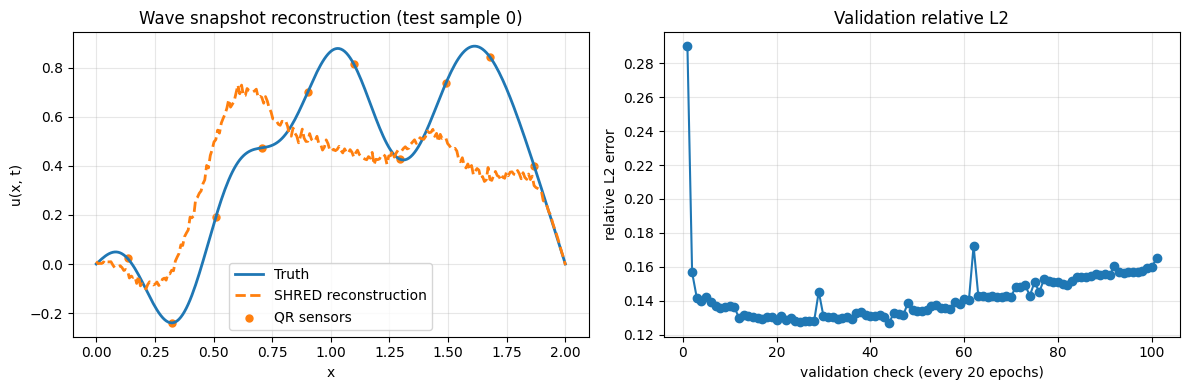

In [ ]:
model.eval()
with torch.no_grad():
    recon = model(test_ds.X).cpu().numpy()

truth = scaler.inverse_transform(test_ds.Y.cpu().numpy())
recon = scaler.inverse_transform(recon)

snapshot_idx = 0
truth_snapshot = truth[snapshot_idx]
recon_snapshot = recon[snapshot_idx]
rel_l2 = np.linalg.norm(recon_snapshot - truth_snapshot) / np.linalg.norm(truth_snapshot)
print(f'Relative L2 error on test set: {rel_l2:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(x, truth_snapshot, label='Truth', linewidth=2)
axes[0].plot(x, recon_snapshot, '--', label='SHRED reconstruction', linewidth=2)
axes[0].scatter(x[sensor_locations], truth_snapshot[sensor_locations], color='tab:orange', s=25, label='QR sensors')
axes[0].set_title(f'Wave snapshot reconstruction (test sample {snapshot_idx})')
axes[0].set_xlabel('x')
axes[0].set_ylabel('u(x, t)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(np.arange(1, len(history) + 1), history.numpy(), marker='o')
axes[1].set_title('Validation relative L2')
axes[1].set_xlabel('validation check (every 20 epochs)')
axes[1].set_ylabel('relative L2 error')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Animation: held-out test set

This animation shows the true wave and the SHRED reconstruction over the held-out test window.

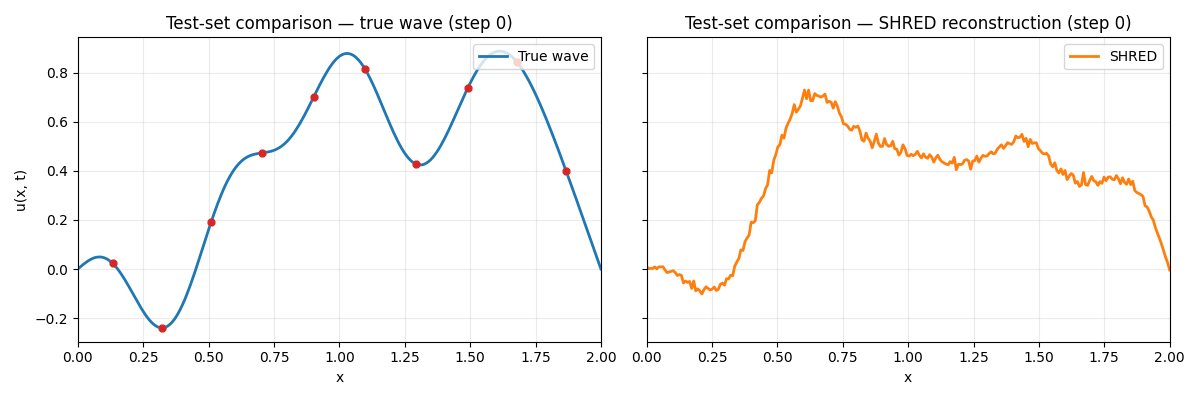

Saved and displayed animation: /Users/kaspervanderhorst/projects/shred/get-shredded/prototyping_tests/wave_shred_test_animation.gif


In [ ]:
from IPython.display import Image, display
from matplotlib.animation import FuncAnimation, PillowWriter


def save_and_display_animation(truth, recon, title_prefix, gif_name, *, fps=10):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    lines = [
        axes[0].plot(x, truth[0], color='tab:blue', lw=2, label='True wave')[0],
        axes[1].plot(x, recon[0], color='tab:orange', lw=2, label='SHRED')[0],
    ]

    for ax in axes:
        ax.set_xlim(x.min(), x.max())
        ax.set_xlabel('x')
        ax.grid(alpha=0.25)

    axes[0].set_title(f'{title_prefix} — true wave')
    axes[1].set_title(f'{title_prefix} — SHRED reconstruction')
    axes[0].set_ylabel('u(x, t)')
    axes[0].legend(loc='upper right')
    axes[1].legend(loc='upper right')

    sensor_marker = axes[0].scatter(
        x[sensor_locations],
        truth[0, sensor_locations],
        color='tab:red',
        s=25,
        label='QR sensors',
        zorder=3,
    )

    plt.tight_layout()

    def update(frame):
        lines[0].set_ydata(truth[frame])
        lines[1].set_ydata(recon[frame])
        sensor_marker.set_offsets(np.column_stack([x[sensor_locations], truth[frame, sensor_locations]]))
        axes[0].set_title(f'{title_prefix} — true wave (step {frame})')
        axes[1].set_title(f'{title_prefix} — SHRED reconstruction (step {frame})')
        return [lines[0], lines[1], sensor_marker]

    gif_path = repo_root / 'prototyping_tests' / gif_name
    anim = FuncAnimation(fig, update, frames=len(truth), interval=80, blit=True)
    anim.save(gif_path, writer=PillowWriter(fps=fps))
    plt.close(fig)
    display(Image(filename=str(gif_path)))
    print(f'Saved and displayed animation: {gif_path}')


truth_test = scaler.inverse_transform(test_ds.Y.cpu().numpy())
recon_test = scaler.inverse_transform(model(test_ds.X).detach().cpu().numpy())
save_and_display_animation(truth_test, recon_test, 'Test-set comparison', 'wave_shred_test_animation.gif', fps=10)

## Notes

This is intentionally a minimal single-sample proof-of-concept. The same pattern can be extended to:

- try different `lags` or sensor counts
- compare random vs QR placement
- add QR/POD baseline reconstruction
- sweep across multiple trajectories or parameter settings